
--- h = 0.05 ---
Max |G(x)| over interval = 1.1000
Solution may not be Stable

--- h = 0.2 ---
Max |G(x)| over interval = 1.4000
Solution may not be Stable

--- h = 0.5 ---
Max |G(x)| over interval = 2.0000
Solution may not be Stable

--- h = 0.9 ---
Max |G(x)| over interval = 2.6754
Solution may not be Stable

--- h = 1.1 ---
Max |G(x)| over interval = 3.1999
Solution may not be Stable


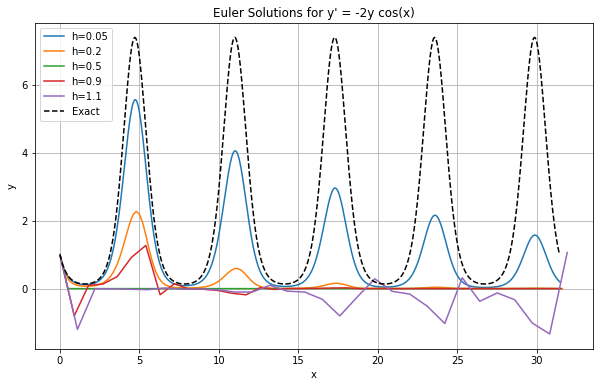

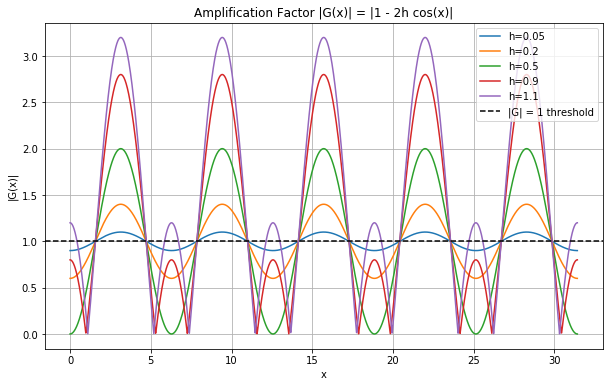

So the problem with trying to determine at what point the solution is stable is that due to the oscillating behavior, 
it is never truly stable. 
For some point on the graph of x, it is a stable solution, for other points it is not. For any value of h, the graph is unstable because the eigenvector is greater than 1 across the whole graph. 


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ODE: y' = -2y cos(x)
def f(x, y):
    return -2 * y * np.cos(x)

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Euler method
def euler(h, x_start, x_end):
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1.0

    for i in range(1, len(x_vals)):
        y_vals[i] = y_vals[i-1] + h * f(x_vals[i-1], y_vals[i-1])

    return x_vals, y_vals

# Stability analysis using amplification factor
def stability_analysis(h, x_vals):
    G = 1 - 2*h*np.cos(x_vals)   # amplification factor
    magnitudes = np.abs(G)

    max_mag = np.max(magnitudes)

    print(f"\n--- h = {h} ---")
    print(f"Max |G(x)| over interval = {max_mag:.4f}")

    if max_mag < 1:
        print("Solution is Stable")
    else:
        print("Solution may not be Stable")

    return G

# Parameters
h_values = [0.05, 0.2, 0.5, 0.9, 1.1]
x_start = 0
x_end = 10 * np.pi

# --- Plot 1: Solutions ---
plt.figure(figsize=(10,6))

for h in h_values:
    x, y = euler(h, x_start, x_end)
    stability_analysis(h, x)
    plt.plot(x, y, label=f"h={h}")

# Exact solution
x_fine = np.linspace(x_start, x_end, 2000)
plt.plot(x_fine, y_exact(x_fine), 'k--', label="Exact")

plt.title("Euler Solutions for y' = -2y cos(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# --- Plot 2: Amplification factor behavior ---
plt.figure(figsize=(10,6))

for h in h_values:
    x = np.linspace(x_start, x_end, 2000)
    G = 1 - 2*h*np.cos(x)
    plt.plot(x, np.abs(G), label=f"h={h}")

plt.axhline(1, linestyle='--', color='black', label='|G| = 1 threshold')

plt.title("Amplification Factor |G(x)| = |1 - 2h cos(x)|")
plt.xlabel("x")
plt.ylabel("|G(x)|")
plt.legend()
plt.grid(True)
plt.show()

print("So the problem with trying to determine at what point the solution is stable is that due to the oscillating behavior, \nit is never truly stable. \nFor some point on the graph of x, it is a stable solution, for other points it is not. For any value of h, the graph is unstable because the eigenvector is greater than 1 across the whole graph. ")